In [168]:
pip install mlxtend pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from itertools import combinations
from collections import defaultdict

In [171]:
# Loading the dataset
groceries_df = pd.read_csv('C:\\Users\\Dell\\Desktop\\7th_sem\\DM\\Apriori\\groceries.csv')

In [172]:
groceries_df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [173]:
# Preprocess the data to sort items in lexicographic order and normalize to <TID, item> pairs
transactions = groceries_df.groupby(['Member_number', 'Date'])['itemDescription'].apply(lambda x: sorted(list(x))).reset_index()
transactions_list = transactions['itemDescription'].tolist()

In [174]:
# Create <TID, items> pairs with unique TID for each transaction
normalized_data = [(idx, items) for idx, items in enumerate(transactions_list)]

# Convert to DataFrame for display
normalized_df = pd.DataFrame(normalized_data, columns=['TID', 'Items'])

# Display the first few rows of the DataFrame
print(normalized_df.head())

   TID                                              Items
0    0  [sausage, semi-finished bread, whole milk, yog...
1    1                  [pastry, salty snack, whole milk]
2    2                     [canned beer, misc. beverages]
3    3                        [hygiene articles, sausage]
4    4                         [pickled vegetables, soda]


In [175]:
normalized_df=groceries_df

In [176]:
num=len(normalized_df) #total transactions
print(num)

38765


In [177]:
normalized_df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [178]:
# Function to calculate support
def calculate_support(itemset, transactions):
    count = sum(1 for transaction in transactions if itemset.issubset(transaction))
    return count / len(transactions)

In [179]:
# Apriori Algorithm Implementation with Visualization
def apriori_with_visualization(transactions, min_support):
    itemsets = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            itemsets[frozenset([item])] += 1

    L = {1: {item for item in itemsets if itemsets[item] / len(transactions) >= min_support}}
    k = 1
    pruned_counts = []

    while L[k]:
        k += 1
        Ck = set([i.union(j) for i in L[k-1] for j in L[k-1] if len(i.union(j)) == k])
        Ck_counts = defaultdict(int)
        
        for transaction in transactions:
            for candidate in Ck:
                if candidate.issubset(transaction):
                    Ck_counts[candidate] += 1
        
        pruned_count = len(Ck)
        L[k] = {item for item in Ck if Ck_counts[item] / len(transactions) >= min_support}
        pruned_count -= len(L[k])
        pruned_counts.append(pruned_count)

    return {k: v for k, v in L.items() if v}, pruned_counts

In [181]:
# Run Apriori algorithm on the preprocessed transactions
transactions_set = [set(transaction) for _, transaction in normalized_data]
min_support = 0.02
frequent_itemsets = apriori(transactions_set, min_support)

AttributeError: 'list' object has no attribute 'size'

In [167]:
# Display frequent itemsets
for k, itemsets in frequent_itemsets.items():
    print(f'{k}-itemsets: {itemsets}')

support-itemsets: Series([], Name: support, dtype: float64)
itemsets-itemsets: Series([], Name: itemsets, dtype: object)


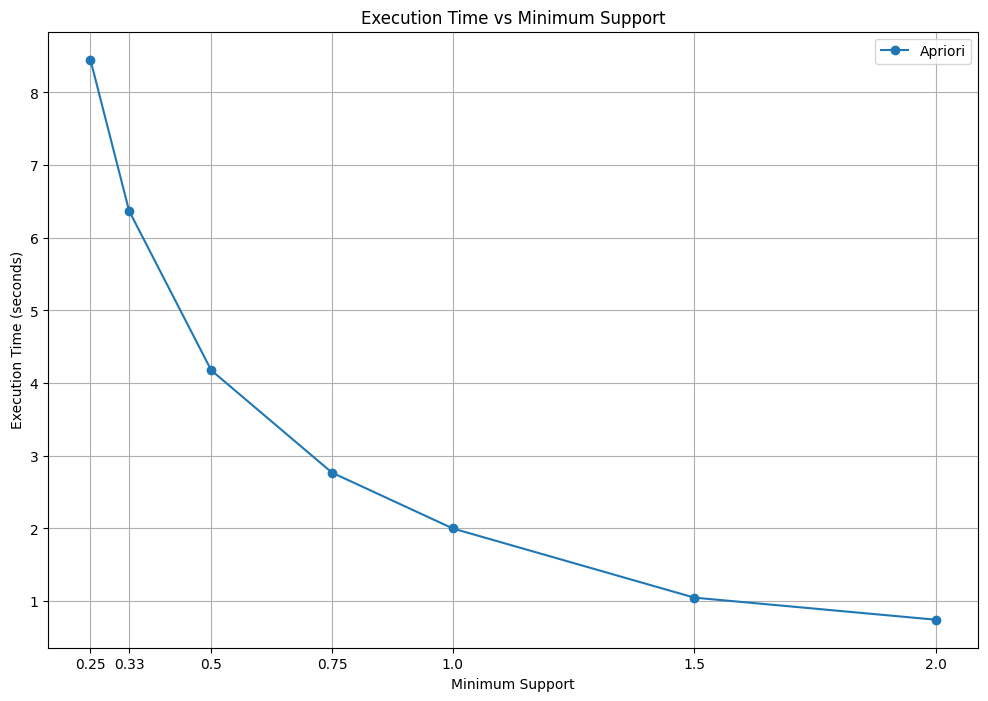

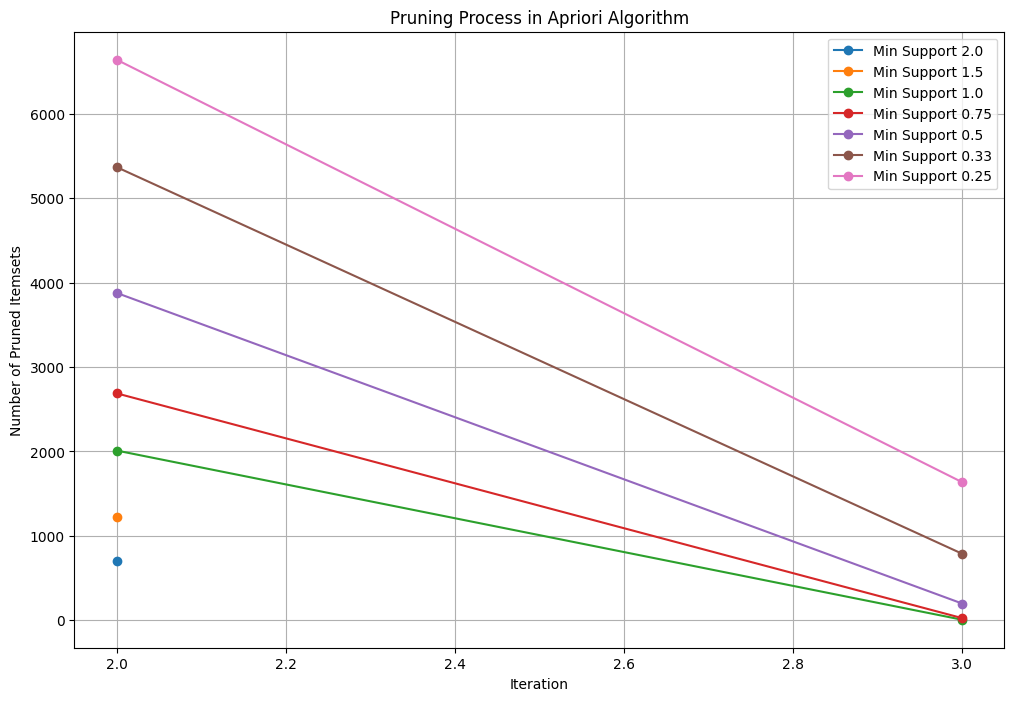

In [135]:
# Measure execution time for different minimum support thresholds
min_supports = [2.0, 1.5, 1.0, 0.75, 0.5, 0.33, 0.25]
execution_times = []
pruning_data = []

transactions_set = [set(transaction) for _, transaction in normalized_data]

for min_support in min_supports:
    start_time = time.time()
    frequent_itemsets, pruned_counts = apriori_with_visualization(transactions_set, min_support / 100)
    end_time = time.time()
    execution_time = end_time - start_time
    execution_times.append(execution_time)
    pruning_data.append(pruned_counts)

# Plot the execution time vs minimum support graph
plt.figure(figsize=(12, 8))
plt.plot(min_supports, execution_times, marker='o', label='Apriori')
plt.xticks(ticks=min_supports, labels=[str(s) for s in min_supports])
plt.title('Execution Time vs Minimum Support')
plt.xlabel('Minimum Support')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the pruning process
plt.figure(figsize=(12, 8))
for idx, pruned_counts in enumerate(pruning_data):
    plt.plot(range(2, 2 + len(pruned_counts)), pruned_counts, marker='o', label=f'Min Support {min_supports[idx]}')
plt.title('Pruning Process in Apriori Algorithm')
plt.xlabel('Iteration')
plt.ylabel('Number of Pruned Itemsets')
plt.legend()
plt.grid(True)
plt.show()

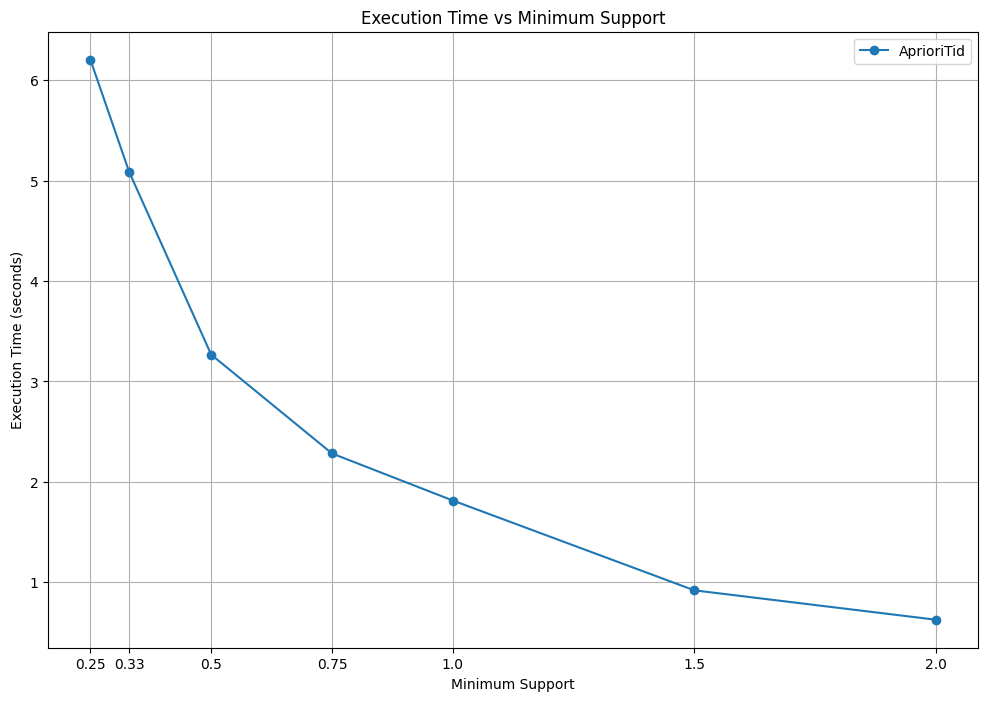

In [122]:
from collections import defaultdict

# Function to calculate support
def calculate_support(itemset, transactions):
    count = sum(1 for transaction in transactions if itemset.issubset(transaction))
    return count / len(transactions)

# AprioriTid Algorithm Implementation
def apriori_tid(transactions, min_support):
    itemsets = defaultdict(int)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            itemsets[frozenset([item])] += 1

    L = {1: {item for item in itemsets if itemsets[item] / len(transactions) >= min_support}}
    k = 1

    Ct = [[tid, {item for item in L[1] if item.issubset(transaction)}] for tid, transaction in enumerate(transactions)]

    while L[k]:
        k += 1
        Ck = set([i.union(j) for i in L[k-1] for j in L[k-1] if len(i.union(j)) == k])
        Ck_counts = defaultdict(int)

        for tid, transaction_itemsets in Ct:
            candidate_itemsets = {candidate for candidate in Ck if candidate.issubset(transaction_itemsets)}
            Ct[tid] = [tid, candidate_itemsets]

            for candidate in candidate_itemsets:
                Ck_counts[candidate] += 1

        L[k] = {item for item in Ck if Ck_counts[item] / len(transactions) >= min_support}

    return {k: v for k, v in L.items() if v}

# Measure execution time for different minimum support thresholds
min_supports = [2.0, 1.5, 1.0, 0.75, 0.5, 0.33, 0.25]
execution_times = []

transactions_set = [set(transaction) for _, transaction in normalized_data]

for min_support in min_supports:
    start_time = time.time()
    frequent_itemsets = apriori_tid(transactions_set, min_support / 100)
    end_time = time.time()
    execution_time = end_time - start_time
    execution_times.append(execution_time)

# Plot the execution time vs minimum support graph
plt.figure(figsize=(12, 8))
plt.plot(min_supports, execution_times, marker='o', label='AprioriTid')
plt.xticks(ticks=min_supports, labels=[str(s) for s in min_supports])
plt.title('Execution Time vs Minimum Support')
plt.xlabel('Minimum Support')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()


In [80]:
# Define minimum support thresholds
# min_supports = np.linspace(0.01, 0.1, 10)
min_supports = [2.0, 1.5, 1.0, 0.75, 0.5, 0.33, 0.25]

In [34]:
# Run Apriori for different minimum support thresholds and record execution times
execution_times = []
for min_support in min_supports:
    execution_time, frequent_itemsets = run_apriori(df, min_support/100)
    execution_times.append(execution_time)

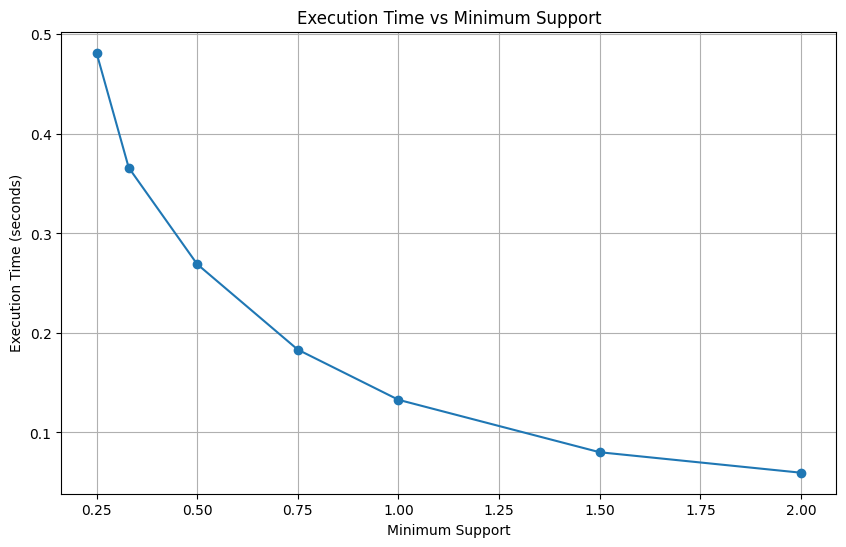

In [38]:
# Plot the execution time vs minimum support graph
plt.figure(figsize=(10, 6))
plt.plot(min_supports, execution_times, marker='o')
plt.title('Execution Time vs Minimum Support')
plt.xlabel('Minimum Support')
plt.ylabel('Execution Time (seconds)')
plt.grid(True)
plt.show()

IMPLEMENTATION OF ALL

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import combinations
from collections import defaultdict

In [40]:

groceries_df = pd.read_csv('C:\\Users\\Dell\\Desktop\\7th_sem\\DM\\Apriori\\groceries.csv')

In [41]:
# Preprocess the data
transactions = groceries_df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

# Helper function to calculate support
def calculate_support(itemset, transactions):
    count = sum(1 for transaction in transactions if itemset.issubset(transaction))
    return count / len(transactions)


In [42]:
# Implement AIS algorithm
def run_ais(transactions, min_support):
    itemsets = []
    for transaction in transactions:
        for item in transaction:
            itemsets.append(frozenset([item]))
    itemsets = set(itemsets)
    
    L = {1: {item for item in itemsets if calculate_support(item, transactions) >= min_support}}
    k = 1
    while L[k]:
        k += 1
        Ck = set([i.union(j) for i in L[k-1] for j in L[k-1] if len(i.union(j)) == k])
        L[k] = {item for item in Ck if calculate_support(item, transactions) >= min_support}
    return L

In [43]:
# Implement SETM algorithm
def run_setm(transactions, min_support):
    itemsets = []
    for transaction in transactions:
        for item in transaction:
            itemsets.append(frozenset([item]))
    itemsets = set(itemsets)
    
    C = [frozenset([item]) for item in itemsets]
    L = []
    while C:
        Lk = []
        for c in C:
            support = calculate_support(c, transactions)
            if support >= min_support:
                Lk.append(c)
        L.extend(Lk)
        C = [i.union(j) for i in Lk for j in Lk if len(i.union(j)) == len(Lk[0]) + 1]
    return L

In [44]:
# Implement Apriori algorithm
def run_apriori(transactions, min_support):
    itemsets = []
    for transaction in transactions:
        for item in transaction:
            itemsets.append(frozenset([item]))
    itemsets = set(itemsets)
    
    L = {1: {item for item in itemsets if calculate_support(item, transactions) >= min_support}}
    k = 1
    while L[k]:
        k += 1
        Ck = set([i.union(j) for i in L[k-1] for j in L[k-1] if len(i.union(j)) == k])
        L[k] = {item for item in Ck if calculate_support(item, transactions) >= min_support}
    return L

In [45]:
# Implement AprioriTid algorithm
def run_apriori_tid(transactions, min_support):
    itemsets = []
    for transaction in transactions:
        for item in transaction:
            itemsets.append(frozenset([item]))
    itemsets = set(itemsets)
    
    T = [{i for i in transaction} for transaction in transactions]
    L = {1: {item for item in itemsets if calculate_support(item, transactions) >= min_support}}
    k = 1
    while L[k]:
        k += 1
        Ck = set([i.union(j) for i in L[k-1] for j in L[k-1] if len(i.union(j)) == k])
        L[k] = {item for item in Ck if calculate_support(item, transactions) >= min_support}
        T = [{item for item in transaction if item in L[k]} for transaction in T]
    return L

In [46]:
# Measure execution time and plot results
min_supports = [2.0, 1.5, 1.0, 0.75, 0.5, 0.33, 0.25]
algorithms = {'AIS': run_ais, 'SETM': run_setm, 'Apriori': run_apriori, 'AprioriTid': run_apriori_tid}
execution_times = {alg: [] for alg in algorithms}


In [47]:
for min_support in min_supports:
    for alg, func in algorithms.items():
        start_time = time.time()
        func(transactions, min_support / 100)
        execution_time = time.time() - start_time
        execution_times[alg].append(execution_time)

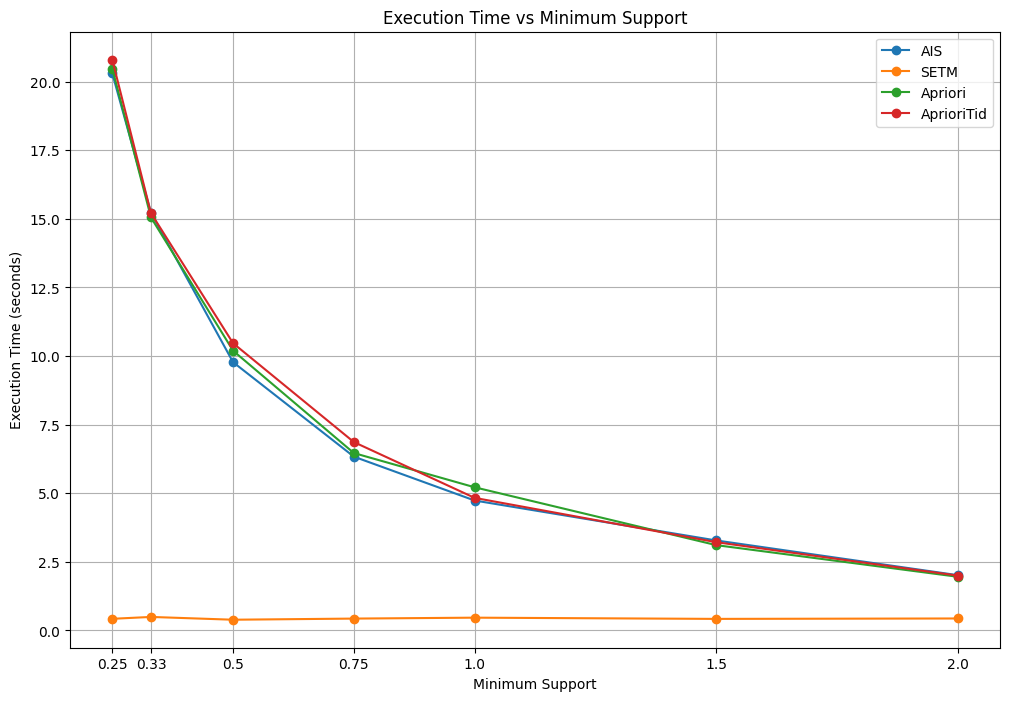

In [48]:
# Plotting results
plt.figure(figsize=(12, 8))
for alg in algorithms:
    plt.plot(min_supports, execution_times[alg], marker='o', label=alg)
plt.xticks(ticks=min_supports, labels=[str(s) for s in min_supports])
plt.title('Execution Time vs Minimum Support')
plt.xlabel('Minimum Support')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

In [124]:
!pip install networkx

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
    --------------------------------------- 0.0/1.7 MB 660.6 kB/s eta 0:00:03
    --------------------------------------- 0.0/1.7 MB 393.8 kB/s eta 0:00:05
   -- ------------------------------------- 0.1/1.7 MB 939.4 kB/s eta 0:00:02
   --- ------------------------------------ 0.2/1.7 MB 919.0 kB/s eta 0:00:02
   ------ --------------------------------- 0.3/1.7 MB 1.3 MB/s eta 0:00:02
   ----------- ---------------------------- 0.5/1.7 MB 1.9 MB/s eta 0:00:01
   -------------- ------------------------- 0.6/1.7 MB 2.1 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.7 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 1.4/1.7 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.1 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [125]:
import pandas as pd
from itertools import combinations
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt


groceries_df = pd.read_csv('C:\\Users\\Dell\\Desktop\\7th_sem\\DM\\Apriori\\groceries.csv')

# Preprocess the data to sort items in lexicographic order
transactions = groceries_df.groupby(['Member_number', 'Date'])['itemDescription'].apply(lambda x: sorted(list(x))).reset_index()
transactions_list = transactions['itemDescription'].tolist()

# Create <TID, items> pairs with unique TID for each transaction
normalized_data = [(idx, items) for idx, items in enumerate(transactions_list)]

# Convert to DataFrame for display
normalized_df = pd.DataFrame(normalized_data, columns=['TID', 'Items'])

# Function to calculate support
def calculate_support(itemset, transactions):
    count = sum(1 for transaction in transactions if itemset.issubset(transaction))
    return count / len(transactions)

# Apriori Algorithm Implementation
def apriori(transactions, min_support):
    itemsets = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            itemsets[frozenset([item])] += 1

    L = {1: {item for item in itemsets if itemsets[item] / len(transactions) >= min_support}}
    k = 1

    while L[k]:
        k += 1
        Ck = set([i.union(j) for i in L[k-1] for j in L[k-1] if len(i.union(j)) == k])
        Ck_counts = defaultdict(int)
        
        for transaction in transactions:
            for candidate in Ck:
                if candidate.issubset(transaction):
                    Ck_counts[candidate] += 1
        
        L[k] = {item for item in Ck if Ck_counts[item] / len(transactions) >= min_support}

    return {k: v for k, v in L.items() if v}

# Run Apriori algorithm on the preprocessed transactions
transactions_set = [set(transaction) for _, transaction in normalized_data]
min_support = 0.02
frequent_itemsets = apriori(transactions_set, min_support)


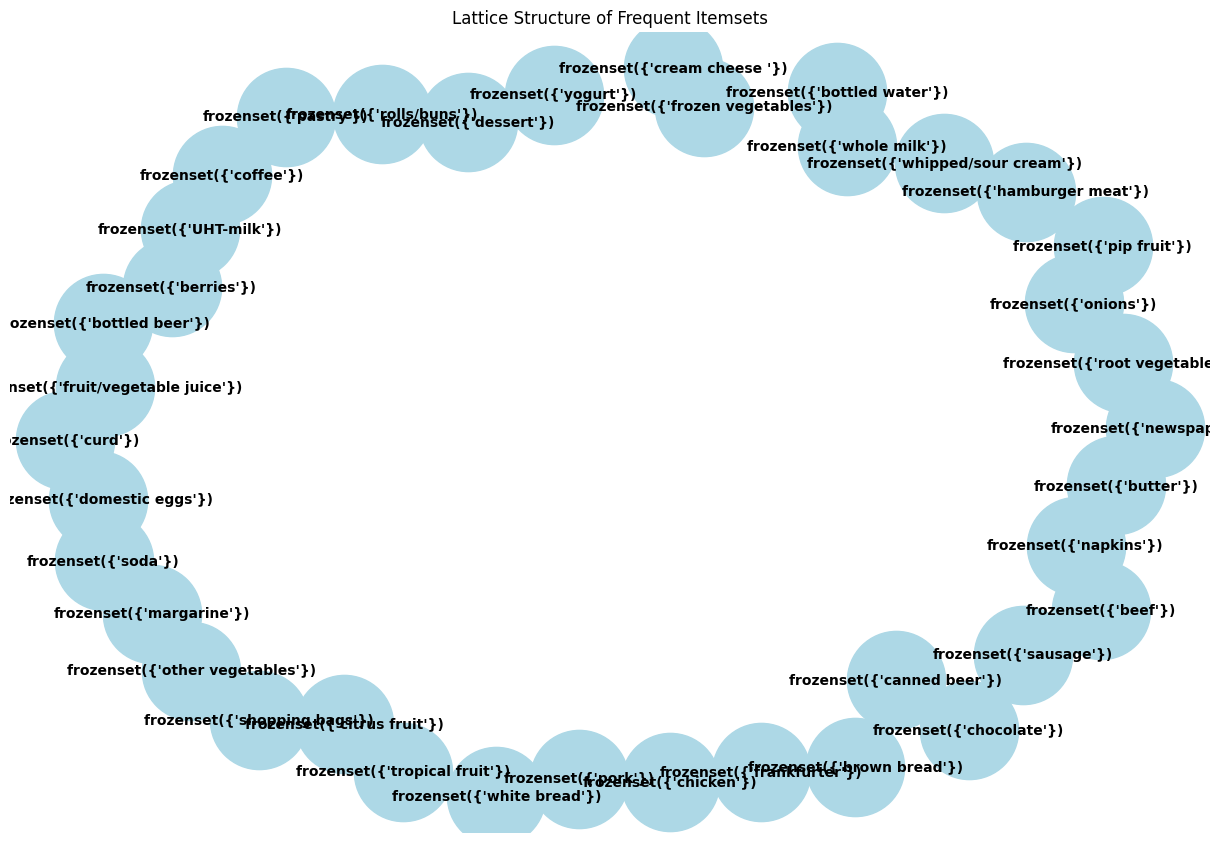

In [126]:
# Create a directed graph to represent the lattice structure
G = nx.DiGraph()

# Add nodes and edges to the graph
for k, itemsets in frequent_itemsets.items():
    for itemset in itemsets:
        G.add_node(itemset)
        if k > 1:
            for subset in combinations(itemset, k - 1):
                subset = frozenset(subset)
                if subset in frequent_itemsets[k - 1]:
                    G.add_edge(subset, itemset)

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # positions for all nodes
nx.draw(G, pos, with_labels=True, node_size=5000, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)
plt.title('Lattice Structure of Frequent Itemsets')
plt.show()
